# Matplotlib 画图入门（一）

**目标**：掌握 matplotlib 最核心的 20% —— 能画出论文/汇报用的线图、散点、柱状、直方图、箱线图，并理解 pyplot 与面向对象两套写法的区别。

**配套理论**：Matplotlib 官方 Tutorial（https://matplotlib.org/stable/tutorials/ ）第 1-3 篇；Python Data Science Handbook（Jake VanderPlas）第 4 章 Visualization（免费在线）。

## 0. 环境检查

**要点**：先确认环境里有没有 matplotlib，没有就装。版本影响 API——很多网上旧教程的写法在 3.x 已废弃（比如 `plt.hist(normed=...)`），先固定版本再学，不这么写会踩"教程代码跑不通"的坑。

In [14]:
import matplotlib
import matplotlib.pyplot as plt

print("matplotlib", matplotlib.__version__)
# 若报 ModuleNotFoundError：终端执行 pip install matplotlib

matplotlib 3.10.6


## 1. 一张图的完整流程

画任何图都只有 4 步：**创建画布(figure) → 在坐标系(axes)上画 → 加装饰(标题/坐标轴/图例) → 显示或保存**。

matplotlib 有两套 API：
- **pyplot 风格**：plt.plot(x, y)，像自动记账本，每次调用自动在当前"活跃"的图上操作；
- **面向对象风格**：fig, ax = plt.subplots(); ax.plot(x, y)，明确持有画布和坐标系对象。

**为什么推荐 ax 风格**： plt 风格隐藏了 figure/axes 的存在，一画多子图、在函数里封装绘图时就失控；ax 风格 1:1 对应底层对象，查文档方便、可复用。

### 1.1 画一条线（先看 plt 风格，理解它做了什么）

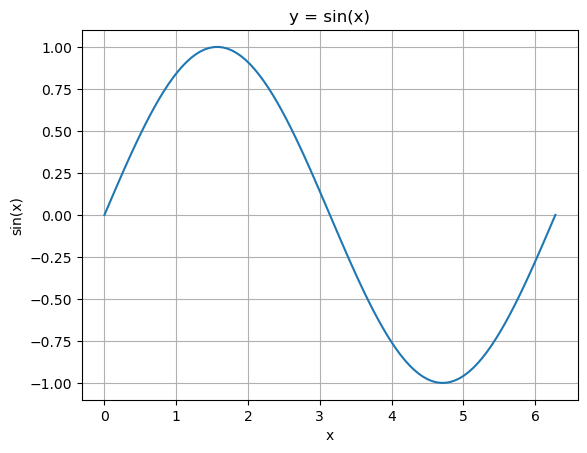

In [15]:
import numpy as np

x = np.linspace(0, 2 * np.pi, 100)  # 0 到 2π 均匀取 100 个点
y = np.sin(x)

plt.plot(x, y)          # 默认蓝色实线
plt.xlabel("x")         # x 轴标签
plt.ylabel("sin(x)")    # y 轴标签
plt.title("y = sin(x)") # 标题
plt.grid(True)          # 网格，便于读数
plt.show()

**要点**： linspace 比  range 好在能生成任意数量的浮点采样点（画函数曲线必须用它）；网格线默认关，论文图通常打开；plt.show() 在脚本里必须有，notebook 里可省但写上无妨。

### 1.2 用 ax 风格重写（推荐写法，以后都用这个）

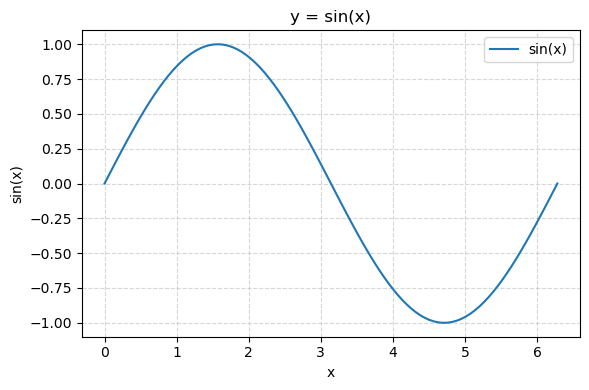

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))  # fig: 6x4 英寸的画布; ax: 画格 numpy 列表
ax.plot(x, y, label="sin(x)")            # label 是图例要用的名字
ax.set_xlabel("x")
ax.set_ylabel("sin(x)")
ax.set_title("y = sin(x)")
ax.grid(True, linestyle="--", alpha=0.5) # 虚线网格，半透明更柔和
ax.legend()                              # 显示图例（前提：plot 时给了 label）
fig.tight_layout()                       # 自动调间距，防止标签被裁
plt.show()

**要点**： label  必须和  legend()  配套，缺一个图例就是空的；tight_layout() 在保存 PDF 时尤其重要，不调用标题/标签会被切掉。

**注意**：plt.plot 画在当前"活跃"的图上；ax.plot 画在指定 ax 上。混用两套 API 是新手最常见的混乱来源。

## 2. 五张基础图（先记"什么时候用什么"）

| 图 | 用途 | 输入 |
|---|---|---|
| plot 线图 | 连续变化趋势（时间序列、函数） | x,y 两个连续变量 |
| scatter 散点图 | 两个变量的关系/分布 | x,y 两个连续变量 |
| bar 柱状图 | 类别对比（离散） | 类别 + 数值 |
| hist 直方图 | 单个变量的分布 | 一个连续变量（原始数据） |
| boxplot 箱线图 | 分布 + 异常值，多组对比 | 一个连续变量（可分组） |

### 2.1 散点图

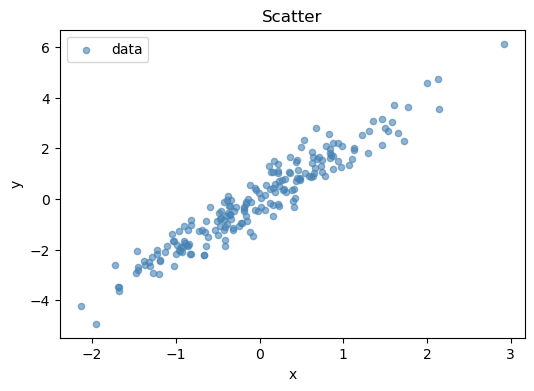

In [5]:
rng = np.random.default_rng(42)          # 固定随机种子，结果可复现
x = rng.normal(0, 1, 200)               # 200 个标准正态样本
y = 2 * x + rng.normal(0, 0.5, 200)     # 带噪声的线性关系

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, s=20, alpha=0.6, c="steelblue", label="data")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Scatter")
ax.legend()
plt.show()

**要点**： 
- `alpha`  控制透明度——点多了以后完全重叠会掩盖密度分布，半透明才能看出浓淡；固定随机种子保证结果可复现（写作业/论文必须可复现，这是基本素养）。
- s=20; s → size,代表点的**面积**,**每个散点的大小**
- `c="steelblue"`, c = color，所有点统一的颜色。

### 2.2 柱状图

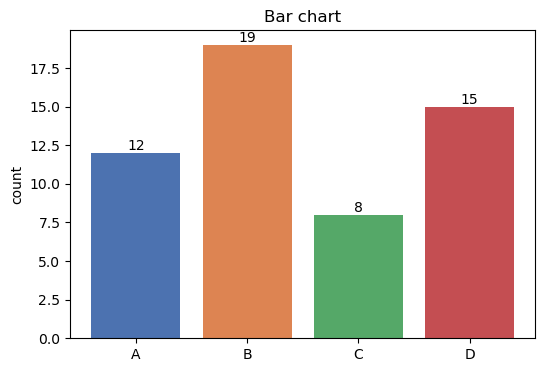

In [20]:
categories = ["A", "B", "C", "D"]
values = [12, 19, 8, 15]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(categories, values, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
ax.bar_label(bars)  # 在柱顶自动标注数值（matplotlib 3.4+）
ax.set_ylabel("count")
ax.set_title("Bar chart")
plt.show()

**要点**： bar_label 自动加数值标签，省去手写循环；颜色用成套调色板（上面是 seaborn 的 colorblind 配色），别用默认红绿蓝——对比度差。

### 2.3 直方图（hist 和 bar 的区别）

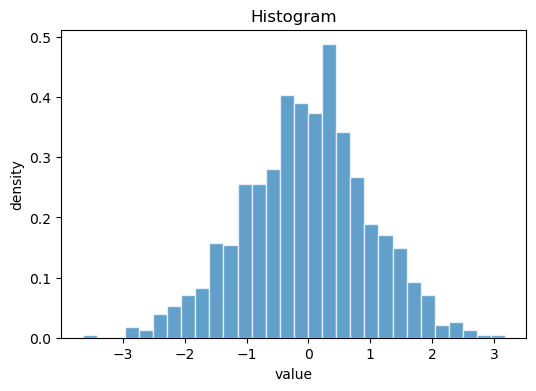

In [7]:
data = rng.normal(0, 1, 1000)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(data, bins=30, density=True, alpha=0.7, edgecolor="white")
ax.set_xlabel("value")
ax.set_ylabel("density")
ax.set_title("Histogram")
plt.show()

**要点**： 
- `bins` 决定柱子数量——太少看不清形状，太多被噪声淹没，30 是个好起点；
- `density=True` 把纵轴变成概率密度，方便后面和理论分布曲线叠加对比；
- **hist 输入是原始数据，bar 输入是已聚合的类别+数值**——两者用途不同，别混。

### 2.4 箱线图

/tmp/ipykernel_4035/3465168908.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=["g1", "g2", "g3"], patch_artist=True)


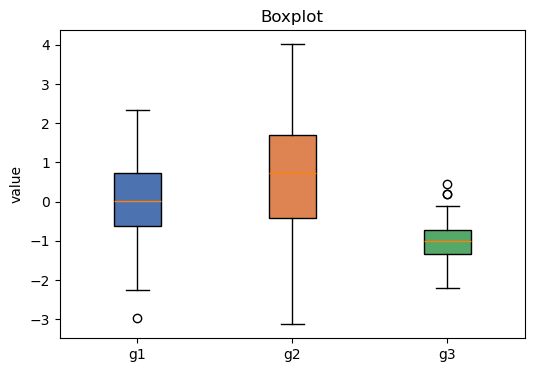

In [8]:
groups = [rng.normal(0, 1, 100), rng.normal(1, 1.5, 100), rng.normal(-1, 0.5, 100)]

fig, ax = plt.subplots(figsize=(6, 4))
bp = ax.boxplot(groups, labels=["g1", "g2", "g3"], patch_artist=True)
for patch, color in zip(bp["boxes"], ["#4C72B0", "#DD8452", "#55A868"]):
    patch.set_facecolor(color)  # patch_artist=True 才能填充颜色
ax.set_ylabel("value")
ax.set_title("Boxplot")
plt.show()

**要点**：
- 箱线图一眼看 5 个统计量——中位数(箱中线)、Q1/Q3(箱上下边)、须(±1.5×IQR)、须外的点是异常值；多组对比时箱线图比直方图省空间得多。
- patch_artist=True, 默认：patch_artist=False, 箱子只是**空心线条边框**，不能填充底色; patch_artist=True 箱体变成可填充颜色的色块对象，你后续可以给箱子上色

bp = ax.boxplot 参数
- bp["boxes"]      # 三个箱体矩形对象
- bp["medians"]    # 中位数横线
- bp["whiskers"]   # 上下须线
- bp["caps"]       # 须两端短横线
- bp["fliers"]     # 异常散点

## 3. 保存图片

In [9]:
fig.savefig("line.png", dpi=150, bbox_inches="tight", facecolor="white")
# 格式选择：png=位图(屏幕用)；svg/pdf=矢量图(论文投稿首选，放大不糊)
# dpi：屏幕 150 够，印刷 300

**要点**： bbox_inches="tight"  自动裁掉多余空白，否则保存的图缺标题或四周留白；论文插图必须矢量格式(svg/pdf)。

## 4. 本节自测题

1.plt.plot 和 ax.plot 的区别是什么？为什么推荐 ax 风格？举一个 plt 风格会出问题的场景。
- plt.plot **在当前被选中的 ax（子画板）上面绘图**, 看不见它选中了哪一块画板，由 matplotlib 后台隐式管理; ax.plot 是你**手动拿到的子图对象**, **明确就在 ax 这一块画板上画线**，目标画板清清楚楚，没有任何隐式、猜测行为; fig, axes = plt.subplots(2, 2) 之后，plt.plot() 只会画到最后被激活的那一个子图；在 for 循环里画多张子图时，plt 风格无法指定 axes[i, j]，所有内容会堆到同一张图上。

2.hist 和 bar 的输入数据分别是什么？各适合什么场景？
hist 输入是原始数据，bar 输入是已聚合的类别+数值; hist 查看连续变量的数据分布, bar 对比不同类别指标大小

3.箱线图上的"须"和"异常值"是怎么定义的（1.5×IQR 具体指什么）？
- 须（whisker，须线端点）的定义
  - **下须**：从箱体底边 $Q_1$向下延伸，一直到 ≥ 下界阈值 的**最远的真实样本点**
  - **上须**：从箱体顶边 $Q_3$ 向上延伸，一直到 ≤ 上界阈值 的**最远的真实样本点**

- 异常值（离群点 fliers）
 - 凡是数值：
   - $x < Q_1 - 1.5\times IQR \quad \text{或者} \quad x> Q_3 + 1.5\times IQR$
   - 这些点**超出上下须的阈值范围**，就被单独画成圆点，标记为异常值。

- 先定义四分位数与 IQR
  - 假设有一组排序后的数据：
    - $Q_1$：下四分位数，25% 的数据 ≤ $Q_1$
    - $Q_3$：上四分位数，75% 的数据 ≤ $Q_3$
- 四分位距 IQR（Inter‑Quartile Range）**
  - $\boldsymbol{IQR = Q_3 - Q_1}$
  - IQR 代表箱体本身的高度，是中间 50% 数据的跨度。
- 1.5×IQR 边界（须的截止阈值）
  - 下界阈值 = Q1 − 1.5 × IQR
  - 上界阈值 = Q3 + 1.5 × IQR

4.画 1000 个点的散点图，为什么一定要加 alpha？
- alpha  控制透明度——点多了以后完全重叠会掩盖密度分布，半透明才能看出浓淡

5.保存论文插图，选什么格式和参数？为什么？
论文插图必须矢量格式(svg/pdf)。